In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import seaborn as sbn
import matplotlib.pyplot as plt

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/predict-the-success-of-bank-telemarketing/sample_submission.csv
/kaggle/input/predict-the-success-of-bank-telemarketing/train.csv
/kaggle/input/predict-the-success-of-bank-telemarketing/test.csv


In [2]:
from sklearn.ensemble import GradientBoostingClassifier, RandomForestClassifier,StackingClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import f1_score,make_scorer,classification_report
from sklearn.model_selection import train_test_split,cross_val_score,RandomizedSearchCV
from sklearn.preprocessing import StandardScaler,OrdinalEncoder, LabelEncoder
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import MinMaxScaler
from xgboost import XGBClassifier,DMatrix
import xgboost as xgb

from sklearn.feature_selection import GenericUnivariateSelect, mutual_info_classif,SelectKBest,chi2
import optuna

### Step1: Get the Data

In [3]:
train = pd.read_csv("/kaggle/input/predict-the-success-of-bank-telemarketing/train.csv",na_values = [" ?", " ??"])
test = pd.read_csv("/kaggle/input/predict-the-success-of-bank-telemarketing/test.csv",na_values = [" ?", " ??"])


In [4]:
train.columns

Index(['last contact date', 'age', 'job', 'marital', 'education', 'default',
       'balance', 'housing', 'loan', 'contact', 'duration', 'campaign',
       'pdays', 'previous', 'poutcome', 'target'],
      dtype='object')

In [5]:
pd.set_option('future.no_silent_downcasting', True)

### Step2: Explore the Data Analysis
- Make a copy of training data.
# `Why one should do it?`
- `To freely manipulate the data the way you want.`
### Steps:
1. `Getting to know data.`
2. `Data Preprocessing (Handling Missing Values).`
3. `Cross tables and Vizualization`

### Input variables:
1. last contact date: last contact date
2. age (numeric)
3. job : type of job
4. marital : marital status (categorical: "married","divorced","single"; note: "divorced" means divorced or widowed)

5. education (categorical: "unknown","secondary","primary","tertiary")
6. default: has credit in default? (binary: "yes","no")
7. balance: average yearly balance, in euros (numeric)
8. housing: has housing loan? (binary: "yes","no")
9. loan: has personal loan? (binary: "yes","no")
10. contact: contact communication type (categorical: "unknown","telephone","cellular")
11. duration: last contact duration, in seconds (numeric)

12. campaign: number of contacts performed during this campaign and for this client (numeric, includes last contact)

13. pdays: number of days that passed by after the client was last contacted from a previous campaign (numeric, -1 means client was not previously contacted)

14. previous: number of contacts performed before this campaign and for this client (numeric)

15. poutcome: outcome of the previous marketing campaign (categorical: "unknown","other","failure","success")

### Output variable (desired target):
16. target: has the client subscribed a term deposit? (binary: "yes","no")

In [6]:
exploration_set  =train.copy()
exploration_set2 = test.copy()


In [7]:
### To check variables type categorical and numerical
exploration_set.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 39211 entries, 0 to 39210
Data columns (total 16 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   last contact date  39211 non-null  object
 1   age                39211 non-null  int64 
 2   job                38982 non-null  object
 3   marital            39211 non-null  object
 4   education          37744 non-null  object
 5   default            39211 non-null  object
 6   balance            39211 non-null  int64 
 7   housing            39211 non-null  object
 8   loan               39211 non-null  object
 9   contact            28875 non-null  object
 10  duration           39211 non-null  int64 
 11  campaign           39211 non-null  int64 
 12  pdays              39211 non-null  int64 
 13  previous           39211 non-null  int64 
 14  poutcome           9760 non-null   object
 15  target             39211 non-null  object
dtypes: int64(6), object(10)
memory usage: 4.

In [8]:
print("Data with missing values:")
sums = exploration_set.isna().sum()
sums
# **************** job, education, contact and poutcome

Data with missing values:


last contact date        0
age                      0
job                    229
marital                  0
education             1467
default                  0
balance                  0
housing                  0
loan                     0
contact              10336
duration                 0
campaign                 0
pdays                    0
previous                 0
poutcome             29451
target                   0
dtype: int64

In [9]:
#******************* summary of numerical variables
num_vars = exploration_set.select_dtypes(include=[np.number])
num_vars.describe()

,age,balance,duration,campaign,pdays,previous
count,39211.000000,39211.000000,39211.000000,39211.000000,39211.000000,39211.000000
mean,42.120247,5441.781719,439.062789,5.108770,72.256051,11.826171
std,12.709352,16365.292065,769.096291,9.890153,160.942593,44.140259
min,18.000000,-8019.000000,0.000000,1.000000,-1.000000,0.000000
25%,33.000000,98.000000,109.000000,1.000000,-1.000000,0.000000
50%,40.000000,549.000000,197.000000,2.000000,-1.000000,0.000000
75%,50.000000,2030.000000,380.000000,4.000000,-1.000000,0.000000
max,95.000000,102127.000000,4918.000000,63.000000,871.000000,275.000000


In [10]:
#******************* summary of categorical variables
cat_vars= exploration_set.select_dtypes(include = "O")
cat_vars.describe()

,last contact date,job,marital,education,default,housing,loan,contact,poutcome,target
count,39211,38982,39211,37744,39211,39211,39211,28875,9760,39211
unique,1013,11,3,3,2,2,2,2,3,2
top,2009-05-15,blue-collar,married,secondary,no,yes,no,cellular,failure,no
freq,313,7776,22691,19584,36954,21657,31820,25030,4949,33384


In [11]:
print("# ********************************************************** Frequency of each catgories ****************************************************** #")
print(exploration_set["job"].value_counts())
print("########################################")
print(exploration_set["education"].value_counts())
print("########################################")
print(exploration_set["marital"].value_counts())
print("########################################")
print(exploration_set["housing"].value_counts())
print("########################################")
print(exploration_set["loan"].value_counts()) ### personal loan
print("########################################")
print(exploration_set["contact"].value_counts())
print("########################################")
print(exploration_set["poutcome"].value_counts())
print("########################################")
print(exploration_set["default"].value_counts())

print("########################################")
print(exploration_set["target"].value_counts()) ### label which I have to predict


# ********************************************************** Frequency of each catgories ****************************************************** #
job
blue-collar      7776
management       7462
technician       6078
admin.           4116
services         3325
self-employed    1862
retired          1824
entrepreneur     1805
unemployed       1685
housemaid        1656
student          1393
Name: count, dtype: int64
########################################
education
secondary    19584
tertiary     11615
primary       6545
Name: count, dtype: int64
########################################
marital
married     22691
single      11250
divorced     5270
Name: count, dtype: int64
########################################
housing
yes    21657
no     17554
Name: count, dtype: int64
########################################
loan
no     31820
yes     7391
Name: count, dtype: int64
########################################
contact
cellular     25030
telephone     3845
Name: count, dtype: int64
#######

############################################################# Data Preprocessing #######################################################################

############################################### Visualizing missing values using pie chart ###################################################



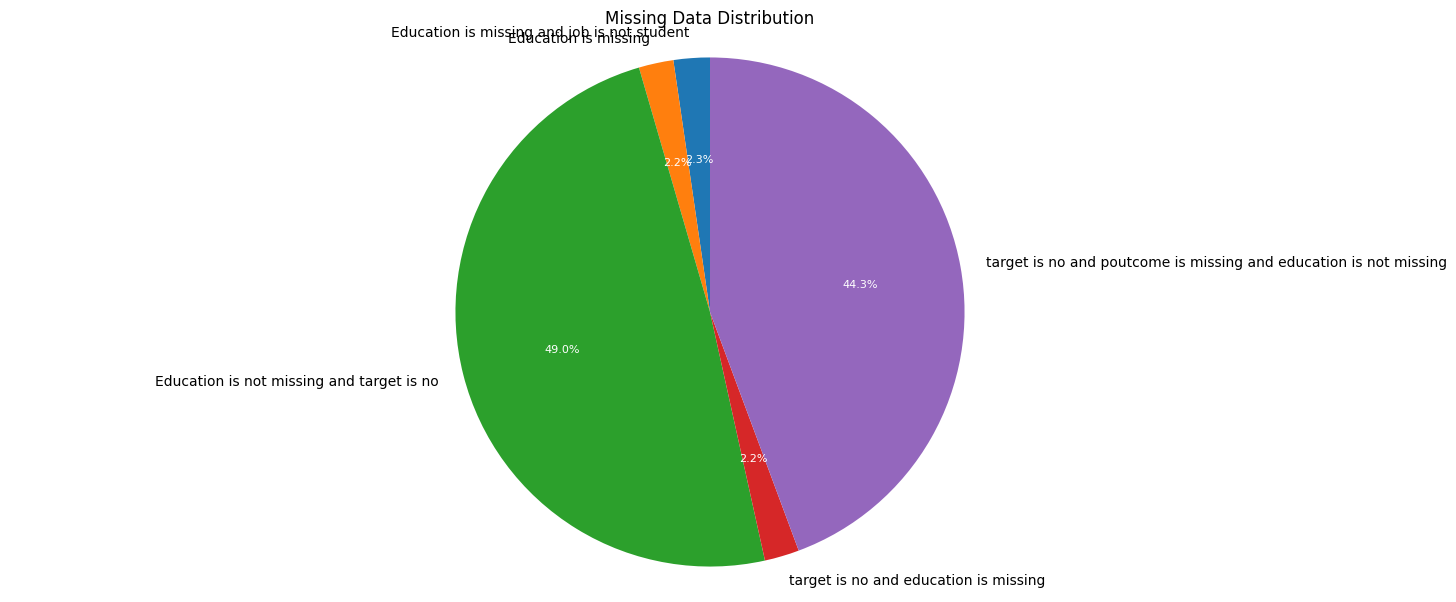

In [12]:
print("############################################################# Data Preprocessing #######################################################################")
missing = exploration_set[exploration_set.isna().any(axis = 1)]
print("""\n############################################### Visualizing missing values using pie chart ###################################################""")
print()



# Data
labels = [
          'Education is missing and job is not student', 
          'Education is missing',
          'Education is not missing and target is no',
        'target is no and education is missing',
        'target is no and poutcome is missing and education is not missing'
]
sizes = [
    missing[(missing['job'] != "student") & (missing['education'].isna())].shape[0],
    missing[(missing['education'].isna()) & (missing["target"] == "no")].shape[0],
    missing[~missing["education"].isna()].shape[0],
    missing[(missing["target"] == "no") & (missing["education"].isna()) ].shape[0],
    missing[(missing["target"] == "no") & (~missing["education"].isna()) & (missing["poutcome"].isna()) ].shape[0]
]


fig1, ax1 = plt.subplots(figsize=(20, 8))  # Adjust the size here (width, height)
wedges, texts, autotexts = ax1.pie(sizes, labels=labels, autopct='%1.1f%%', startangle=90)

# Adjusting label properties
for text in texts:
    text.set_fontsize(10)  # Set font size for labels
for autotext in autotexts:
    autotext.set_color('white')  # Set color for percentage text
    autotext.set_fontsize(8)      # Set font size for percentage text

# Equal aspect ratio ensures that pie is drawn as a circle.
ax1.axis('equal')  
plt.title('Missing Data Distribution')

# Adjust layout to make room for labels
plt.subplots_adjust(left=0.1, right=0.8, top=0.8, bottom=0.1)
plt.show()



############################################# dropping completely the rows which are missing ##########################

###################################### Correlation between independent variables using heatmap #################################################

 ############################### correlation is +ve either it is weak or strong ########################


<Axes: >

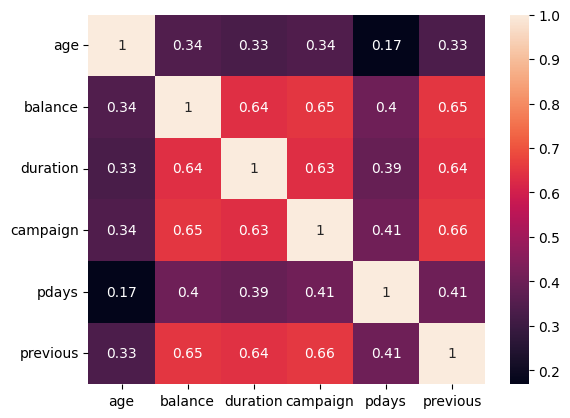

In [13]:
print("############################################# dropping completely the rows which are missing ##########################")
data = exploration_set.dropna(axis = 0)
correlation = data.select_dtypes(include = [np.number]).corr()
print("\n###################################### Correlation between independent variables using heatmap #################################################")
print("\n ############################### correlation is +ve either it is weak or strong ########################")
sbn.heatmap(correlation, annot = True)

############################################################# Cross tables and Data Vizualization ################################################

######################################################## Extracting column names ################################################################
Index(['last contact date', 'age', 'job', 'marital', 'education', 'default',
       'balance', 'housing', 'loan', 'contact', 'duration', 'campaign',
       'pdays', 'previous', 'poutcome', 'target'],
      dtype='object')

############################### Person who has taken personal loan and house loan #################################
loan           no       yes
housing                    
no       0.304514  0.110087
yes      0.433037  0.152363


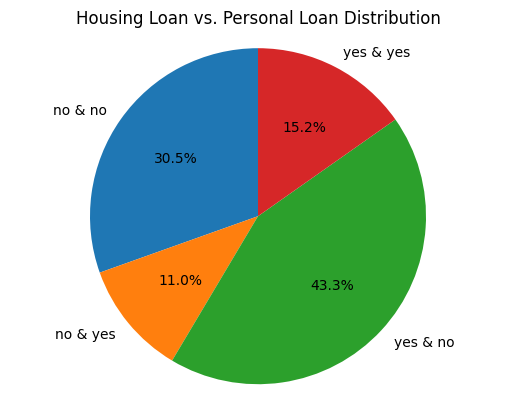

In [14]:
print("############################################################# Cross tables and Data Vizualization ################################################")
print("\n######################################################## Extracting column names ################################################################")
print(data.columns)

print("\n############################### Person who has taken personal loan and house loan #################################")
housing_loan = pd.crosstab(index = data["housing"],columns=data["loan"],normalize = True)
print(housing_loan)
labels = [f"{housing} & {loan}" for housing in housing_loan.index for loan in housing_loan.columns]
sizes = housing_loan.values.flatten()
fig1, ax1 = plt.subplots()
ax1.pie(sizes, labels=labels, autopct='%1.1f%%', startangle=90)
ax1.axis('equal')  # Equal aspect ratio ensures that pie is drawn as a circle.

plt.title('Housing Loan vs. Personal Loan Distribution')
plt.show()


####################################### Housing Loan Vs Target #############################################

target         no       yes
housing                    
no       0.230134  0.184467
yes      0.451049  0.134350
############################## Vizualing it using Pie Chart ####################################################



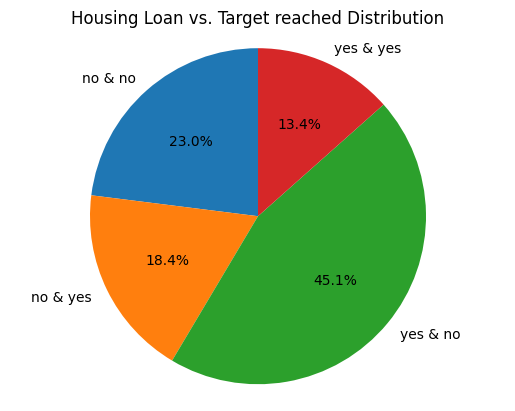

In [15]:
print("####################################### Housing Loan Vs Target #############################################\n")
housing_target = pd.crosstab(index = data["housing"],columns = data["target"],normalize = True)
print(housing_target)
print("############################## Vizualing it using Pie Chart ####################################################\n")
labels = [f"{housing} & {target}" for housing in housing_target.index for target in housing_target.columns]
sizes = housing_target.values.flatten()
fig1, ax1 = plt.subplots()
ax1.pie(sizes, labels=labels, autopct='%1.1f%%', startangle=90)
ax1.axis('equal')  # Equal aspect ratio ensures that pie is drawn as a circle.

plt.title('Housing Loan vs. Target reached Distribution')
plt.show()


####################################################### Target #######################################################################

col_0      count
target          
no      0.681182
yes     0.318818


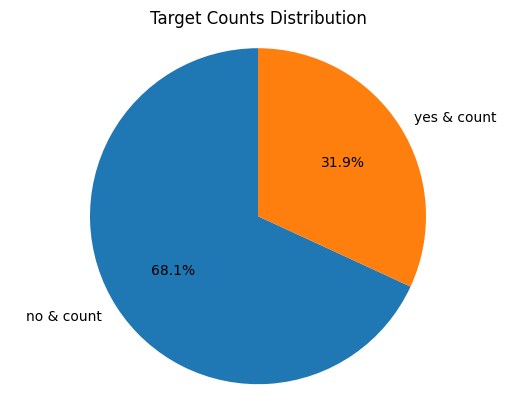

In [16]:
print("####################################################### Target #######################################################################\n")
target_pie = pd.crosstab(index = data["target"],columns ="count",normalize = True)

print(target_pie)
labels = [f"{target} & {counts}" for target in target_pie.index for counts in target_pie.columns]
sizes = target_pie.values.flatten()
fig1, ax1 = plt.subplots()
ax1.pie(sizes, labels=labels, autopct='%1.1f%%', startangle=90)
ax1.axis('equal')

plt.title('Target Counts Distribution')
plt.show()

###################################################### Salary ########################################################################


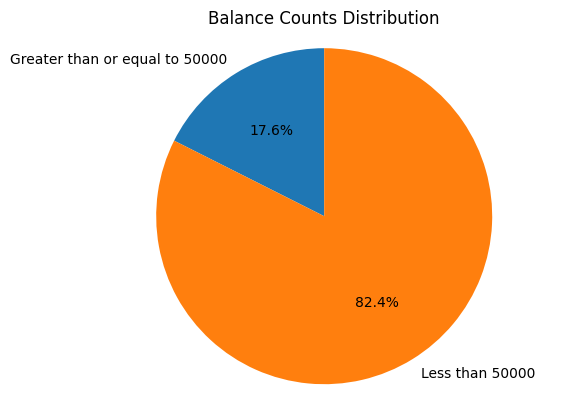

In [17]:
print("###################################################### Salary ########################################################################")
sal_stat = data.apply(lambda x: "Greater than or equal to 50000" if x.balance >= 50000 else "Less than 50000",axis = 1)
sal_stat_counts= pd.crosstab(index = sal_stat,columns = "count",normalize = True)
labels = [f"{balance}" for balance in sal_stat_counts.index for counts in sal_stat_counts.columns]
sizes = sal_stat_counts.values.flatten()
fig1, ax1 = plt.subplots()
ax1.pie(sizes, labels=labels, autopct='%1.1f%%', startangle=90)
ax1.axis('equal')

plt.title('Balance Counts Distribution')
plt.show()

/opt/conda/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


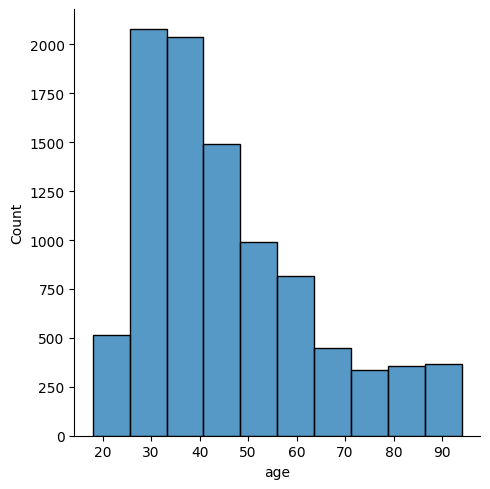

In [18]:
sbn.displot(data["age"],bins = 10, kde = False);


<Axes: ylabel='age'>

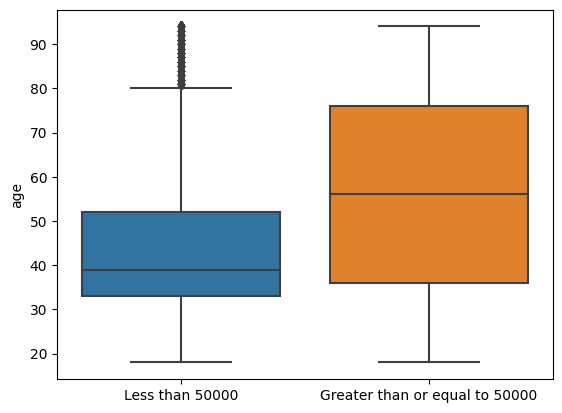

In [19]:
sbn.boxplot(x = sal_stat, y = data["age"])

In [20]:
job_sal = pd.crosstab(index = data["job"], columns = sal_stat,normalize = True)
education_sal = pd.crosstab(index = data["education"], columns = sal_stat,normalize = True)
print("################################################ Job vd Balance ###############################################################################\n")
print(job_sal)
print("############################################################ Education Vs Balance ##############################################################\n")
print(education_sal)

################################################ Job vd Balance ###############################################################################

col_0          Greater than or equal to 50000  Less than 50000
job                                                           
admin.                               0.000000         0.090273
blue-collar                          0.000000         0.129053
entrepreneur                         0.033588         0.051918
housemaid                            0.037084         0.043971
management                           0.000000         0.148231
retired                              0.000212         0.038673
self-employed                        0.034223         0.052871
services                             0.000000         0.056792
student                              0.034435         0.052448
technician                           0.000000         0.109981
unemployed                           0.036236         0.050011
####################################

In [21]:
bal = exploration_set2["balance"].unique()
# bal[np.argmin(bal)]
# exploration_set["pdays"].mean(),exploration_set["pdays"].median()


### 1. Feature Extraction
### 2. Imputing
### 3. Feature Selection

In [22]:
################################### Replacing yes with 1 and no with 0 and some feature engineering #############################################
def replace_and_drop_data(df):
    ### replacing applicable for both train.csv and test.csv
    df['loan'] = df['loan'].replace({"yes": 1, "no": 0}).astype(np.int64)
    df['housing'] = df['housing'].replace({"yes": 1, "no": 0}).astype(np.int64)
    df['default'] = df['default'].replace({"yes": 1, "no": 0}).astype(np.int64)
    df["poutcome"] = df["poutcome"].replace({"other": np.nan})
    ### inconsistent values changed
    mean_balance = df[df['balance'] >= 0]['balance'].mean()
    ### feature engineering
    # 'days_since_last_contact' from 'last contact date'
    df['last contact date'] = pd.to_datetime(df['last contact date'])
    max_contact_date = df['last contact date'].max()
    df['days_since_last_contact'] = (max_contact_date - df['last contact date']).dt.days
    # balance_group from balance
    df['balance'] = df['balance'].apply(lambda x: mean_balance if x < 0 else x)
    df["balance_group"] = df['balance'].apply(lambda x: 1 if x >= 50000 else 0)
	## housing and personal
    df['housing_personal'] = df['housing'] & df['loan']
    ## credit in default, housing loan and personal loan
    df['credit_housing_personal'] = df["default"] & df['housing'] & df['loan']
    ## is adult
    df['is_adult'] = (df['age'] >= 18).astype(np.int64)
    ## has any loan
    df['loan_taken'] = df['loan'] | df['housing']
    ### is adult and taken any loan
    df["adult_loan"] = df['is_adult'] & df["loan_taken"]
    ###  previously_contacted
    df["previously_contacted"] = df["pdays"].apply(lambda x: 1 if x != 1 else 0)
    ### contact frequency
    # Create the contact_frequency feature
    df['contact_frequency'] = df.apply(lambda x: x['previous'] / (x['pdays'] + 1) if x['pdays'] != -1 else 0, axis=1)
    ### contact recency
    df['contact_recency'] = df['pdays'].apply(lambda x: 'never' if x == -1 else ('recent' if x <= 30 else 'long_ago'))
    ### imputed mean where pdays is -1 cause it means not previously contact
    df["pdays"] = df["pdays"].apply(lambda x: round(df["pdays"].mean()) if x == -1 else  x)
    ### transformations to scale them 0 to 3.5
    df.pdays = df.pdays.apply(lambda x: np.log10(x) if x>0 else 0)
    df.previous = df.previous.apply(lambda x: np.log10(x) if x> 0 else 0)
    df.age = df.age.apply(lambda x: np.log10(x) if x > 0 else 0)
    median = df.balance.median()
    df.balance = df.balance.apply(lambda x: (np.log10(x))/2 if x> 0 else 0)
    df.days_since_last_contact = df.days_since_last_contact.apply(lambda x: (np.log10(x)) if x > 0 else 0)
    ### uneccesary column dropping from train and test.csv
    df = df.drop(['last contact date','marital'], axis=1)
    try:    
        df['target'] = df['target'].replace({"yes": 1, "no": 0}).astype(np.int64)
    except:
        pass
    finally:
        return df

# Apply the function to both datasets
data1 = replace_and_drop_data(exploration_set)
data2 = replace_and_drop_data(exploration_set2)


In [23]:
data1.isna().sum()

age                            0
job                          229
education                   1467
default                        0
balance                        0
housing                        0
loan                           0
contact                    10336
duration                       0
campaign                       0
pdays                          0
previous                       0
poutcome                   32011
target                         0
days_since_last_contact        0
balance_group                  0
housing_personal               0
credit_housing_personal        0
is_adult                       0
loan_taken                     0
adult_loan                     0
previously_contacted           0
contact_frequency              0
contact_recency                0
dtype: int64

<Axes: >

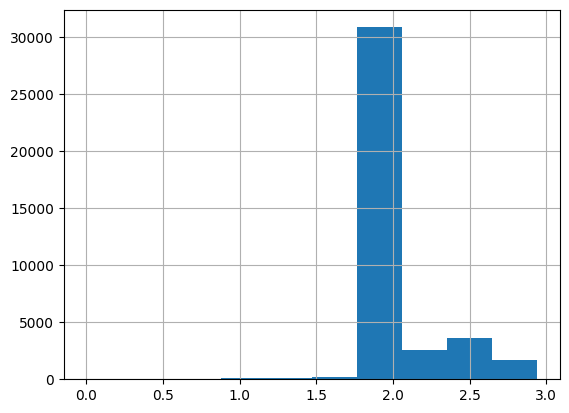

In [24]:
data1.pdays.hist()

In [25]:
# data1.pdays.apply(lambda x: np.log10(x) if x!= 0 else 0).hist()
# data1.previous.apply(lambda x: np.log10(x) if x!= 0 else 0).hist()
# data1.age.apply(lambda x: np.log10(x) if x!= 0 else 0).hist()
# median = data1.balance.median()
# data1.balance.apply(lambda x: (np.log10(x))/2 if x!= 0 else 0).hist()
# data1.days_since_last_contact.apply(lambda x: (np.log10(x)) if x!= 0 else 0).hist()


### Data Preprocessing
- **Handling Missing Values:**
    - `I used LabelEncoder class to convert categorical values to number and fill the missing values.`
- **Seperating features and label**
    - `I used train_test_split function from sklearn.model_selection.`
- **Feature Scaling:**
    - `Every feature was at different scale to rescale them to 0 to 1. 
        I used StandardScaler class from sklearn.preprocessing.`

    

In [26]:
num_cols = ["age", "balance", "duration", "campaign", "pdays", "previous", "days_since_last_contact","contact_frequency"]
missing_cat_cols = ["poutcome", "contact", "job", "education"]
binary_cols = ["balance_group","previously_contacted","housing_personal","housing",'adult_loan',"is_adult","loan_taken"]
without_encoded_cols = ["poutcome", "contact", "job", "education" ,"contact_recency"]
def transformer():
    ## Imputation
    cat_imputer = SimpleImputer(strategy='most_frequent')
    data1[missing_cat_cols] = cat_imputer.fit_transform(data1[missing_cat_cols])
    data2[missing_cat_cols] = cat_imputer.transform(data2[missing_cat_cols])
    
    ### Convert to categorical
    for col in missing_cat_cols:
        data1[col] = data1[col].astype('category')
        data2[col] = data2[col].astype('category')
    
    ### Encoding
    encoder = OrdinalEncoder()
    data1[without_encoded_cols ] = encoder.fit_transform(data1[without_encoded_cols]).astype(np.int64)
    data2[without_encoded_cols ] = encoder.transform(data2[without_encoded_cols]).astype(np.int64)
    
    # ### Standardization
    scaler = MinMaxScaler()
    data1[num_cols] = scaler.fit_transform(data1[num_cols])
    data2[num_cols] = scaler.transform(data2[num_cols])

# Assuming data1 and data2 are your DataFrames
transformer()
data1.head()


,age,job,education,default,balance,housing,loan,contact,duration,campaign,...,days_since_last_contact,balance_group,housing_personal,credit_housing_personal,is_adult,loan_taken,adult_loan,previously_contacted,contact_frequency,contact_recency
0,0.221054,1,1,0,0.561155,1,0,0,0.072590,0.016129,...,0.919307,0,0,0,1,1,1,1,0.000018,0
1,0.637733,9,1,0,0.547544,1,0,1,0.032534,0.000000,...,0.871453,0,0,0,1,1,1,1,0.000000,1
2,0.537310,1,1,0,0.627891,0,0,0,0.066287,0.000000,...,0.527164,0,0,0,1,0,0,1,0.000000,1
3,0.364373,0,1,0,0.518152,1,0,1,0.021147,0.032258,...,0.883753,0,0,0,1,1,1,1,0.000000,1
4,0.326789,2,2,0,0.426564,0,0,0,0.090484,0.016129,...,0.996295,0,0,0,1,0,0,1,0.000000,1


<Axes: >

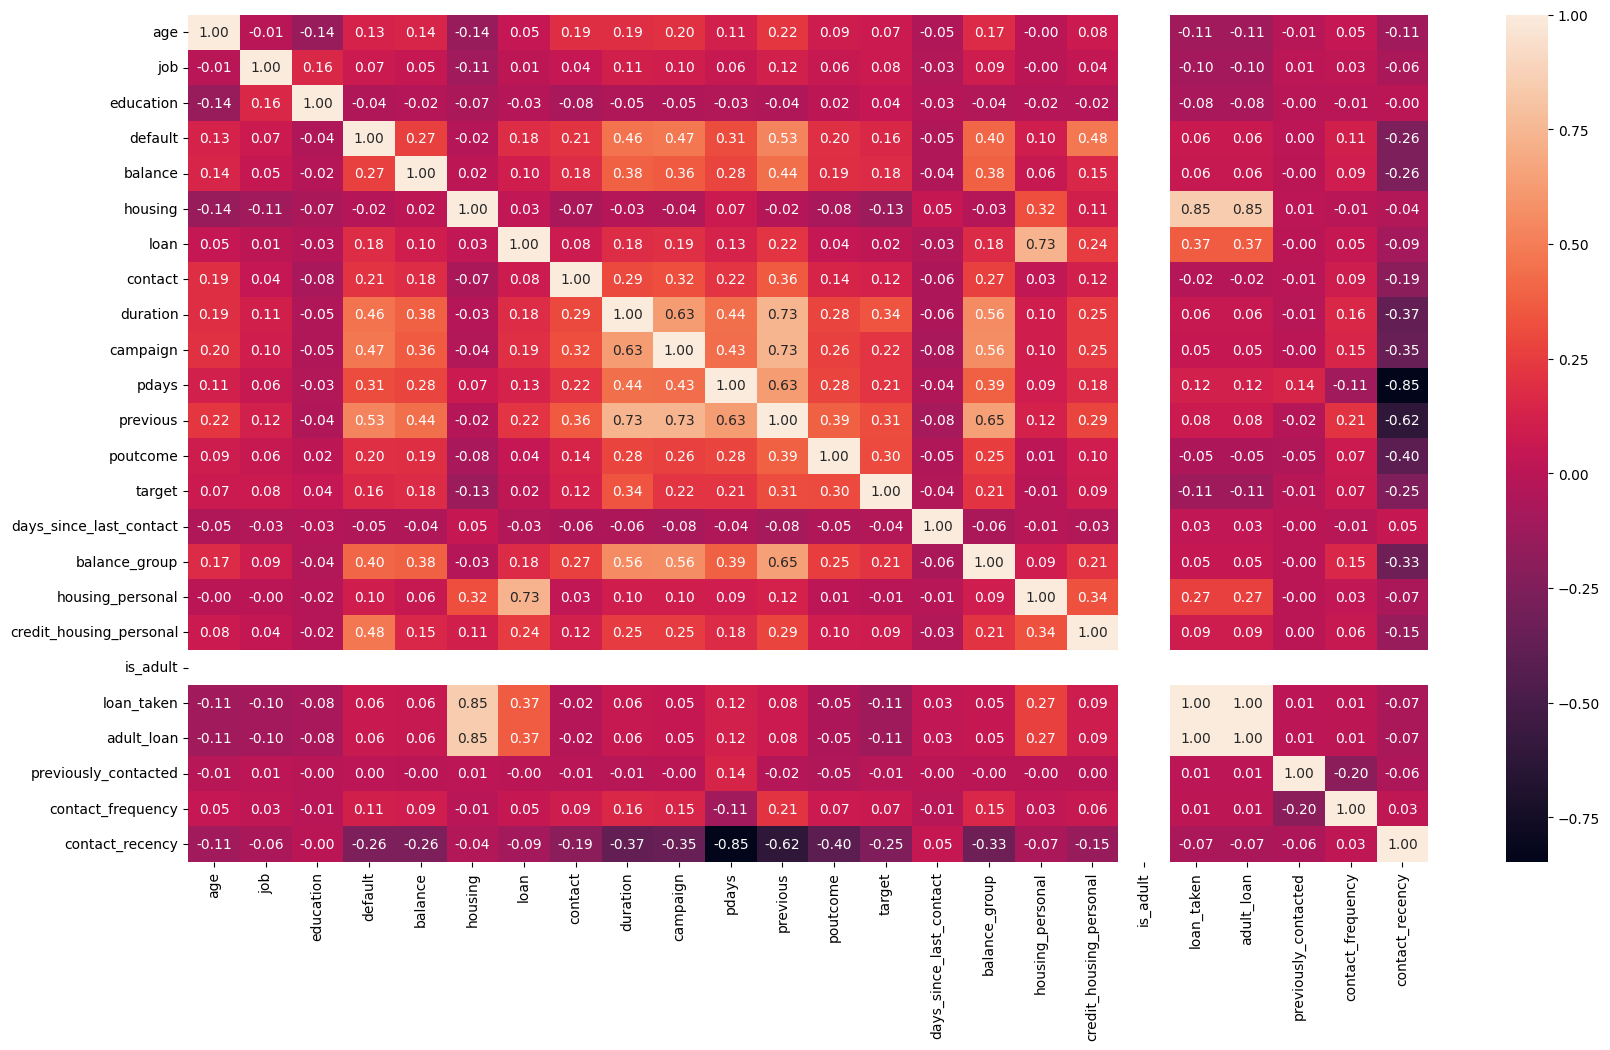

In [27]:
plt.figure(figsize=(20,11))
matrix = data1.corr()
sbn.heatmap(matrix,annot=True,fmt = ".2f")

## Fitting
1. Standardized Data
2. Normalized Data


### After Standardization

In [28]:
print("############################################################# Data Preprocessing Completed ########################################################\n")
print("1. Using SimpleImputer to handle missing values\n")
print("2. Using Ordinal Encoder class to encode missing cat cols\n")
print("3. Splitting X and y into train and test set\n")
print("4. Using StandardScaler scaled features for both training and test set\n")
print("I did not scale first because it can leak the data.")

############################################################# Data Preprocessing Completed ########################################################

1. Using SimpleImputer to handle missing values

2. Using Ordinal Encoder class to encode missing cat cols

3. Splitting X and y into train and test set

4. Using StandardScaler scaled features for both training and test set

I did not scale first because it can leak the data.


#### Feature Selection

In [29]:
selector = GenericUnivariateSelect(score_func=mutual_info_classif,mode="k_best",param=20)
X = selector.fit_transform(data1.drop("target",axis = 1),data1.target)
y = data1.target
submission_set = selector.transform(data2)
X_train,X_test,y_train,y_test = train_test_split(X,y, test_size = 0.33, random_state = 7,stratify=y)


### Select and train models
- `I used several model to see which one predicts the best`
    - **Models used**
        1. `Decision Tree Classifier`
        2. `Random Forest Classifier`
        3. `KNN Classifier`



In [30]:
params = {'subsample': 0.75, 'reg_lambda': 0.2333333333333333, 'reg_alpha': 0.31622776601683794, 'n_estimators': 290, 'min_child_weight': 4, 'max_depth': 18, 'learning_rate': 0.01, 'gamma': 0.2, 'colsample_bytree': 0.3}
models = {
    "XGBClassifier": [XGBClassifier(**params,random_state = 0,scale_pos_weight=len(y_train) / sum(y_train)),0.0,{"target":[]}]
}

In [31]:
for i in models:
    models[i][0].fit(X_train,y_train)
    y_pred = models[i][0].predict(X_test)
    models[i][2]["target"]  = np.where(models[i][0].predict(submission_set) == 1,"yes","no")
    score = f1_score(y_test,y_pred,average="macro")
    models[i][1] = score
    print("Correctly classified samples: {} and Misclassified samples: {}".format(len(y_test[y_pred == y_test]),len(y_test[y_pred != y_test])))
    print("F1 macro score: {}".format(score))
    print(classification_report(y_test,y_pred))

    print("Cross val score for {} is: {}".format(i,cross_val_score(estimator=models[i][0],X=X,y=y,scoring="f1_macro",cv=5)))

Correctly classified samples: 11059 and Misclassified samples: 1881
F1 macro score: 0.7592530160581963
              precision    recall  f1-score   support

           0       0.95      0.87      0.91     11017
           1       0.51      0.76      0.61      1923

    accuracy                           0.85     12940
   macro avg       0.73      0.81      0.76     12940
weighted avg       0.89      0.85      0.87     12940

Cross val score for XGBClassifier is: [0.76725524 0.75190714 0.76253708 0.76103606 0.75479663]


### Best Model
- **`XGBClassifier`**

### Step 8: Model tuning


In [32]:
xgb = XGBClassifier(random_state=0, scale_pos_weight = len(y_train[y_train == 0]) / len(y_train[y_train == 1]))
param_grid = {
    'n_estimators': np.arange(100, 500, 100),
    'max_depth': np.arange(4, 20, 4),
    'learning_rate': np.logspace(-3, 0, 5),
    'colsample_bytree': np.linspace(0.5, 1.0, 4),
    'subsample': np.linspace(0.6, 0.9, 4),
    'gamma': np.logspace(-3, -1, 5),
    'min_child_weight': np.arange(1, 6, 2),
    'reg_lambda': np.logspace(-2, 0, 5),
    'reg_alpha': np.logspace(-2, 1, 4)
}



random_search = RandomizedSearchCV(
    estimator=xgb,
    param_distributions=param_grid,
    scoring='f1_macro',
    n_iter=100,
    cv=5,
    verbose=2,
    n_jobs=-1,
    random_state=42
)

random_search.fit(X_train, y_train)

print("Best parameters found: ", random_search.best_params_)
print("Best F1 score: ", random_search.best_score_)

best_xgb = random_search.best_estimator_
y_pred = best_xgb.predict(X_test)
print(classification_report(y_test, y_pred))

cross_val_scores = cross_val_score(best_xgb, X=X_train, y=y_train, scoring="f1_macro", cv=5)
print("Cross-validation F1 scores:", cross_val_scores)


Fitting 5 folds for each of 100 candidates, totalling 500 fits
[CV] END colsample_bytree=0.6666666666666666, gamma=0.0031622776601683794, learning_rate=0.005623413251903491, max_depth=16, min_child_weight=1, n_estimators=100, reg_alpha=0.1, reg_lambda=1.0, subsample=0.8; total time=   5.5s
[CV] END colsample_bytree=0.6666666666666666, gamma=0.01, learning_rate=0.1778279410038923, max_depth=4, min_child_weight=5, n_estimators=400, reg_alpha=10.0, reg_lambda=0.03162277660168379, subsample=0.9; total time=   2.3s
[CV] END colsample_bytree=0.6666666666666666, gamma=0.01, learning_rate=0.1778279410038923, max_depth=4, min_child_weight=5, n_estimators=400, reg_alpha=10.0, reg_lambda=0.03162277660168379, subsample=0.9; total time=   2.3s
[CV] END colsample_bytree=0.6666666666666666, gamma=0.0031622776601683794, learning_rate=1.0, max_depth=8, min_child_weight=3, n_estimators=200, reg_alpha=0.01, reg_lambda=0.31622776601683794, subsample=0.6; total time=   2.3s
[CV] END colsample_bytree=1.0, g

/opt/conda/lib/python3.10/site-packages/joblib/externals/loky/process_executor.py:752: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


[CV] END colsample_bytree=0.6666666666666666, gamma=0.0031622776601683794, learning_rate=0.005623413251903491, max_depth=16, min_child_weight=1, n_estimators=100, reg_alpha=0.1, reg_lambda=1.0, subsample=0.8; total time=   5.5s
[CV] END colsample_bytree=0.6666666666666666, gamma=0.01, learning_rate=0.1778279410038923, max_depth=4, min_child_weight=5, n_estimators=400, reg_alpha=10.0, reg_lambda=0.03162277660168379, subsample=0.9; total time=   2.4s
[CV] END colsample_bytree=0.6666666666666666, gamma=0.0031622776601683794, learning_rate=1.0, max_depth=8, min_child_weight=3, n_estimators=200, reg_alpha=0.01, reg_lambda=0.31622776601683794, subsample=0.6; total time=   2.2s
[CV] END colsample_bytree=0.6666666666666666, gamma=0.0031622776601683794, learning_rate=1.0, max_depth=8, min_child_weight=3, n_estimators=200, reg_alpha=0.01, reg_lambda=0.31622776601683794, subsample=0.6; total time=   2.2s
[CV] END colsample_bytree=1.0, gamma=0.1, learning_rate=0.001, max_depth=8, min_child_weight=

In [33]:
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       0.95      0.88      0.92     11017
           1       0.53      0.74      0.61      1923

    accuracy                           0.86     12940
   macro avg       0.74      0.81      0.77     12940
weighted avg       0.89      0.86      0.87     12940



### Step 9:  Output

In [34]:
output = pd.DataFrame({'id': range(len(y_pred)),
                       'target': np.where(y_pred ==1, "yes", "no")})
output.to_csv('submission.csv', index=False)
print("Done")

Done
